# 문화누리카드 카테고리별 수요·공급 2SFCA / E2SFCA

서울시 100m 격자를 수요지, 문화누리카드 가맹점을 공급지로 사용해 10개 카테고리별 2SFCA와 E2SFCA를 계산한다.

- 수요: `일반인_i + a_c × 문화누리대상자_i`
- 공급: 합의한 카테고리·시설별 상대 공급량 `S_j`
- 기본 2SFCA: 권역 안의 OD에 동일 가중치 적용
- E2SFCA: 가까운 시설에 더 큰 구간 가중치 적용
- 최종 결과: 100m 격자마다 10개 카테고리의 2SFCA·E2SFCA 원점수와 백분위

> 여기서 `a_c`는 실증적으로 추정된 이용확률 배수가 아니라 카드 이용실적과 일반인 여가참여 양상을 반영한 **카테고리별 상대수요 보정계수**다.


## 1. 수요 가중치의 근거

최근 2023~2025년 문화누리카드 이용건수는 도서와 영상에 집중되었다. 10개 카테고리로 재분류한 대략적 비중은 도서 45%, 영상 36%, 미술 7%, 관광지 4% 순이다. 근거 범위는 `260713_(공공데이터) 서울시 문화누리카드 이용 및 발급 실적 관련(2021~2025).xlsx`의 `2023!BC1:CE26`, `2025!BD1:CF26`이다.

일반인 비교자료는 `국민여가활동조사_2021_2025_필요컬럼_통합.xlsx`의 `국민여가활동조사2021_2025필요컬럼_통합!C1:AW50239`이다. 일반인 조사에서는 관광·체육·영상 참여가 비교적 보편적이고 도서·음악·공연·스포츠관람은 상대적으로 선택적이었다.

| 카테고리 | $a_c$ | 설계 이유 |
|---|---:|---|
| 도서 | 3.50 | 카드 이용이 가장 집중된 분야 |
| 영상 | 3.00 | 영화 중심 이용건수가 매우 높음 |
| 미술 | 2.50 | 공예·사진관·전시 이용을 합치면 비교적 높음 |
| 음악 | 2.00 | 카드 이용은 작고 일반인 참여도도 낮은 편 |
| 공연 | 2.00 | 일반 관람 빈도가 낮아 카드 지원 효과 반영 |
| 문화체험 | 1.50 | 대상자 이용은 있으나 일반인 참여도도 적지 않음 |
| 체육용품 | 1.50 | 카드 구매 유인은 있으나 이용건수는 낮음 |
| 체육시설 | 1.25 | 일반인 체육활동 참여가 보편적이어서 추가 가중을 작게 설정 |
| 관광지 | 1.25 | 일반인의 관광 참여율이 높아 대상자 특화성이 약함 |
| 스포츠관람 | 1.00 | 카드 이용건수가 극히 적어 추가 가중 없음 |

가중치는 최근 카드 이용구조로 가중평균했을 때 약 3이 되도록 설계해 기존 단일 `a=3` 수준을 유지한다. 총인구에는 대상자가 포함되어 있으므로 일반인은 `max(추정_인구수-문화누리대상자_추정_인구수, 0)`으로 계산한다.


## 2. 10개 카테고리별 공급량 기준, 계산식과 사용 데이터

### 2.1 공통 원칙

시설 $j$의 공급량을 $S_j$로 정의한다. 모든 카테고리에 같은 물리적 단위를 강제로 적용하지 않고, 자료가 있는 카테고리는 객석·면적·관람객·경기장 운영규모를 사용하며 자료가 없는 카테고리는 합의한 등급값을 사용한다.

공연은 객석 수, 나머지 등급형 카테고리는 상대지수이므로 원점수를 카테고리 사이에서 직접 더하지 않는다. 각 카테고리의 2SFCA/E2SFCA를 따로 계산한 후 카테고리 내부 백분위로 변환하여 종합한다.

| 사용 데이터 | 주요 필드·범위 | 공급량 계산에서의 역할 |
|---|---|---|
| `서울시_문화누리카드_가맹점_2026.gpkg` | `가맹점_ID`, `가맹점명`, `중분류`, `소분류`, `주소`, `시군구` | 10개 카테고리 분류, 명칭 기반 시설유형 판정 |
| `DB검색_공연시설DB.xlsx` | `DB검색_공연시설DB`, 시설명·공연장명·총객석수·객석수·지역·주소 | 공연시설 운영 객석 수와 가맹점 매칭 |
| `등록·신고+체육시설_20260805203156.csv` | 서울시 소계의 시설유형별 시설 수·총면적 | 체육시설 유형별 평균면적과 상대 공급지수 |
| `국가유산청 궁능유적본부_4대궁 관람객 수 현황_20251231.csv` | 일별 유료·무료 관람객 | 궁궐 연간 관람객 합계 |
| `서울시설공단_서울어린이대공원 일별 이용객수 현황_20251231.csv` | 일자·입장인원 | 서울어린이대공원 연간 이용객 합계 |
| 사용자가 제공한 경기장 좌석·경기 수 표 | 좌석 수, 연평균 경기 수 | 스포츠관람의 경기장 운영규모 계산 |

명칭 기반 규칙은 완전한 시설조사 대신 적용하는 정책적 대체 기준이다. 각 가맹점에 적용된 `공급량`, `공급기준`, 공연의 `공연DB매칭명`은 `문화누리_가맹점_카테고리별_공급량.csv`에 저장하여 사후 검토할 수 있게 한다.

### 2.2 도서

서점별 면적·재고·열람석 자료를 일괄 확보하기 어려우므로 모든 도서 가맹점을 같은 공급시설로 본다.

$$S_j=1$$

- 사용 데이터: 문화누리 가맹점 GPKG의 `중분류=도서`
- 개별 서점 규모는 반영하지 않는다.

### 2.3 문화체험

수용인원 공공자료가 없으므로 가맹점명에서 확인되는 운영 형태를 사용한다.

| 시설 형태 | 판정 예시 | $S_j$ |
|---|---|---:|
| 공공·복합·다중 프로그램 시설 | 문화센터, 수련관, 복합문화공간, 문화재단, 문화원 | 1.5 |
| 일반 체험시설 | 공방, 체험교실, 문화교육원, 전통문화 체험시설 | 1.0 |
| 소규모 개인·예약제 시설 | 스튜디오, 작업실, 예약제 시설 | 0.7 |
| 비대면·이동형·기획형 서비스 | 체험키트 판매, 온라인 강의·온라인 체험, 배송·출장 체험, 행사기획 | 0.5 |

- 사용 데이터: 문화누리 가맹점 GPKG의 가맹점명과 `중분류=문화체험`
- 체험키트와 온라인 체험은 제외하지 않고 합의한 최저 등급 0.5를 부여한다.

### 2.4 음악

음반점·악기점 등 음악 가맹점의 매장규모와 재고를 비교할 공통자료가 없으므로 동일 공급량을 적용한다.

$$S_j=1$$

- 사용 데이터: 문화누리 가맹점 GPKG의 `중분류=음악`

### 2.5 영상

영상 117개는 가맹점명과 소분류를 사용해 대형 멀티플렉스, 기타 실제 영화관, TV·비디오, 비시설 영화업체로 구분한다.

| 구분 | 가맹점 수 | 판정 기준 | $S_j$ |
|---|---:|---|---:|
| 대형 멀티플렉스 | 73 | CGV 30개, 롯데시네마 22개, 메가박스 21개 | 3.0 |
| 독립·기타 실제 영화관 | 15 | 영화 소분류 중 위 3개 체인이 아니며 실제 상영시설인 곳 | 2.0 |
| TV·케이블 업체 | 26 | `소분류=TV` | 1.0 |
| 우성비디오 | 1 | 비디오 판매·대여점 | 1.0 |
| 넥스트엔터테인먼트월드(씨네Q) | 1 | 영화관 운영회사 주소 | 0.5 |
| 배리어프리영화위원회 | 1 | 영화 관련 단체·사무실 | 0.5 |

- 사용 데이터: 문화누리 가맹점 GPKG의 `중분류=영상`, `소분류`, 가맹점명
- 실제 상영관인 `씨네Q 신도림` 등은 기타 실제 영화관으로 보아 2.0을 적용한다.

### 2.6 체육시설

서울시 등록·신고 체육시설 자료에서 시설유형 $k$의 평균면적을 계산한다.

$$Q_k=\frac{\text{서울시 유형별 총면적}_k}{\text{서울시 유형별 시설 수}_k}$$

주요 유형 평균면적의 중앙값 $Q_{med}=443.7366\,m^2$를 기준으로 제곱근 변환하고 0.5~3.0으로 제한한다.

$$S_j=\operatorname{clip}\left(\sqrt{\frac{Q_k}{443.7366}},\ 0.5,\ 3.0\right)$$

| 시설유형 | 평균면적(㎡) | $S_j$ |
|---|---:|---:|
| 종합체육시설 | 3,243.4 | 2.70 |
| 빙상장 | 2,417.8 | 2.33 |
| 수영장 | 1,116.7 | 1.59 |
| 체육교습업 | 627.7 | 1.19 |
| 무도장 | 583.6 | 1.15 |
| 인공암벽장 | 553.7 | 1.12 |
| 골프연습장 | 443.7 | 1.00 |
| 가상야구 | 415.2 | 0.97 |
| 체력단련장 | 411.4 | 0.96 |
| 썰매장 | 362.7 | 0.90 |
| 당구장 | 177.7 | 0.63 |
| 체육도장 | 154.2 | 0.59 |
| 무도학원 | 152.1 | 0.59 |
| 자료와 명칭을 매칭할 수 없는 시설 | - | 1.00 |

- 사용 데이터: 등록·신고 체육시설 CSV와 문화누리 가맹점명
- 스포츠센터·수영·클라이밍·골프·헬스·당구·태권도 등의 명칭 키워드로 시설유형을 연결한다.

### 2.7 체육용품

매장면적과 재고량을 공통으로 비교할 수 없으므로 모든 체육용품 가맹점에 동일 공급량을 적용한다.

$$S_j=1$$

- 사용 데이터: 문화누리 가맹점 GPKG의 `중분류=체육용품`

### 2.8 미술

미술은 `사진관`, `공예`, `전시` 소분류와 가맹점명을 함께 사용한다. 전시장 면적자료가 없으므로 시설의 운영형태를 등급화한다.

| 시설 형태 | 판정 예시 | $S_j$ |
|---|---|---:|
| 공공 대형 미술시설 | 국립·시립·구립, 문화재단, 예술의전당의 전시시설 | 2.0 |
| 일반 미술관·전시시설 | 미술관, 박물관, 전시관, 아트센터 | 1.5 |
| 일반 미술서비스 | 갤러리, 화랑, 소규모 전시공간, 사진관, 공방, 공예점 | 1.0 |
| 비시설·판매·기획 중심 | 미술기획사, 온라인 판매, 작품 유통·판매, 렌탈, 대관 전문업체 | 0.5 |

- 사용 데이터: 문화누리 가맹점 GPKG의 가맹점명, `중분류=미술`, 소분류 `사진관·공예·전시`
- 기획·온라인·유통·렌탈·대관 규칙을 우선 적용하고, 그다음 공공 대형시설과 일반 전시시설을 판정한다.

### 2.9 공연

공연시설DB와 매칭되는 시설은 현재 운영 중인 객석 수를 공급량으로 사용한다.

$$S_j=\sum_{h\in j,\ h\neq\text{폐관}}\text{객석 수}_h$$

| 상태 | $S_j$ |
|---|---:|
| 공연시설DB 매칭, 운영 객석 수 양수 | 운영 중인 공연장 객석 합계 |
| 내부 공연장 중 폐관 표기 | 해당 공연장 객석 제외 |
| DB 미매칭 또는 객석 수 0 | 100석 |
| 확인된 극단·공연기획사·오페라단·오케스트라 등의 소극장 | 미매칭 시 100석 |

- 사용 데이터: `DB검색_공연시설DB.xlsx`와 문화누리 가맹점명·시군구
- 시설명과 공연장명을 정규화하여 우선 정확 매칭하고, 같은 자치구 안에서 포함관계가 확인되는 명칭을 보조 매칭한다.
- 100석은 공연DB의 민간 소규모 공연장 분포에서 얻은 대표 중앙값이다.

### 2.10 스포츠관람

경기장형 가맹점의 원 공급규모는 좌석 수와 연평균 경기 수의 곱이다. 한 경기장을 두 구단이 공유하면 구단별로 나눈 값을 사용한다.

$$Q_j=\frac{\text{좌석 수}_j\times\text{연평균 경기 수}_j}{\text{공유 구단 수}_j}$$

경기장형 시설의 최소·최대 원 공급규모인 $Q_{min}=90{,}140$, $Q_{max}=1{,}834{,}360$을 사용해 0.5~3.0으로 선형 정규화한다.

$$S_j=0.5+2.5\times\frac{Q_j-90{,}140}{1{,}834{,}360-90{,}140}$$

| 구단·시설 | $S_j$ |
|---|---:|
| FC서울 | 3.00 |
| LG트윈스·두산베어스 | 각각 2.84 |
| 키움히어로즈 | 2.11 |
| 서울 삼성 썬더스 | 0.89 |
| IBK기업은행·OK금융그룹·대한항공·흥국생명 | 각각 0.89 |
| 서울 SK 나이츠 | 0.63 |
| GS칼텍스·서울 우리카드 | 각각 0.50 |
| 응원용품·굿즈숍 6개 | 각각 0.50 |

- 사용 데이터: 사용자가 제공한 경기장별 좌석 수·연평균 경기 수 표
- 서울 외 4개 구단은 잠실실내체육관의 원 공급규모 359,743을 대체값으로 사용한다.
- 굿즈숍은 경기장 공급시설이 아니므로 최저 공급량 0.5를 적용한다.

### 2.11 관광지

관광지 공급량은 공공데이터에서 연간 관람객 수를 확인할 수 있는 시설과 확인할 수 없는 시설을 구분하여 산정한다.

#### 1) 국가유산청 궁능유적본부 관람객 데이터

경복궁·창덕궁·창경궁·덕수궁은 국가유산청 궁능유적본부의 일별 관람객 자료를 이용한다.

- 사용 파일: `국가유산청 궁능유적본부_4대궁 관람객 수 현황_20251231.csv`
- 자료 기간: 2025년 1월 1일~12월 31일
- 사용 열: 각 시설의 `유료`, `무료` 관람객
- 참고 시설: 종묘
- 내국인·영어권·일어권·중어권·기타외국인 열은 유료·무료 관람객의 구성항목이므로 별도로 더하지 않는다.

시설별 연간 관람객 수는 다음과 같이 계산한다.

$$
Q_j
=
\sum_{d=1}^{365}
\left(
\text{유료 관람객}_{jd}
+
\text{무료 관람객}_{jd}
\right)
$$

여기서 $Q_j$는 관광지 $j$의 2025년 연간 관람객 수이고, $d$는 날짜다.

| 시설 | 유료 관람객 | 무료 관람객 | 연간 관람객 $Q_j$ |
|---|---:|---:|---:|
| 경복궁 | 2,377,305 | 4,509,345 | 6,886,650 |
| 창덕궁 | 894,768 | 1,324,479 | 2,219,247 |
| 창경궁 | 473,317 | 1,128,885 | 1,602,202 |
| 덕수궁 | 675,644 | 2,886,238 | 3,561,882 |
| 종묘 | 258,656 | 502,966 | 761,622 |

종묘는 상대지수 기준값을 계산할 때는 사용하지만, 문화누리 관광지 가맹점 목록에 없으면 실제 2SFCA 공급시설에는 포함하지 않는다.

#### 2) 서울어린이대공원 이용객 데이터

서울어린이대공원은 다음 공공데이터의 일별 입장인원을 합산한다.

- 사용 파일: `서울시설공단_서울어린이대공원 일별 이용객수 현황_20251231.csv`
- 사용 열: `일자`, `입장인원`
- 2025년 자료 합계: 8,038,010명

$$
Q_{\text{서울어린이대공원}}
=
\sum_d \text{일별 입장인원}_d
=
8{,}038{,}010
$$

해당 파일에는 2025년 9월 18일 자료가 없지만, 누락된 하루가 연간 상대지수에 미치는 영향이 작으므로 제공된 자료의 합계를 그대로 사용한다.

#### 3) 관람객 기반 공급지수

국가유산청 5개 시설과 서울어린이대공원을 합친 6개 기준시설의 연간 관람객 중앙값은 2,890,564.5명이다.

대규모 관광지가 결과를 과도하게 지배하지 않도록 중앙값 대비 제곱근 상대지수로 변환하고, 공급량을 0.5~3.0 범위로 제한한다.

$$
S_j
=
\operatorname{clip}
\left(
\sqrt{
\frac{Q_j}{2{,}890{,}564.5}
},
\ 0.5,\ 3.0
\right)
$$

| 관광지 | 연간 관람객 | 공급량 $S_j$ |
|---|---:|---:|
| 경복궁 | 6,886,650 | 1.54 |
| 창덕궁 | 2,219,247 | 0.88 |
| 창경궁 | 1,602,202 | 0.74 |
| 덕수궁 | 3,561,882 | 1.11 |
| 종묘 | 761,622 | 0.51 |
| 서울어린이대공원 | 8,038,010 | 1.67 |

경복궁·창덕궁·창경궁·덕수궁·서울어린이대공원은 문화누리 가맹점명과 일치하는 시설에 위 공급량을 적용한다.

#### 4) 관람객 자료가 없는 관광지

연간 관람객 자료가 없는 관광지는 문화누리 가맹점의 소분류와 가맹점명을 이용해 공급량을 부여한다.

| 시설 형태 | 판정 예시 | 공급량 $S_j$ |
|---|---|---:|
| 대형 관광시설 | 대형 테마파크, 아쿠아리움, 전망대, N서울타워, 케이블카, 대형 동·식물원 | 1.5 |
| 일반 고정형 관광시설 | 일반 관광명소, 중소형 테마시설, 시티투어버스 대표 승차지 | 1.0 |
| 소규모 체험·휴양시설 | 체험관광, 온천, 캠핑장, 소규모 휴양시설 | 0.7 |
| 고정 관광시설이 아닌 판매점 | 캠핑용품점 및 아웃도어 판매점 | 분석 제외, $S_j=0$ |

공급량 적용 순서는 다음과 같다.

1. 공공데이터와 일치하는 관광지는 관람객 기반 공급지수를 적용한다.
2. 공공데이터가 없으면 대형 관광시설 여부를 판정한다.
3. 이후 소분류에 따라 일반시설 또는 소규모 체험·휴양시설로 분류한다.
4. 실제 관광시설이 아닌 판매점은 분석에서 제외한다.

분석에서 제외하는 가맹점은 다음과 같다.

- HCC(헬리녹스 크리에이티브 센터)
- gocamp(주식회사 고캠프)
- 가야미
- 강서캠핑
- 고릴라캠핑 서울강변테크노마트점
- 쏙텐트
- 에이스아웃도어

관광지 카테고리의 공급량 기준은 다음과 같이 요약된다.

$$
S_j
=
\begin{cases}
\operatorname{clip}
\left(
\sqrt{Q_j/2{,}890{,}564.5},
0.5,
3.0
\right), & \text{관람객 자료가 있는 시설}\\
1.5, & \text{대형 관광시설}\\
1.0, & \text{일반 고정형 관광시설}\\
0.7, & \text{소규모 체험·온천·휴양시설}\\
0, & \text{고정 관광시설이 아닌 판매점}
\end{cases}
$$

### 2.12 최종 적용 요약

| 카테고리 | 최종 공급량 범위·단위 | 핵심 근거 |
|---|---|---|
| 도서 | 1 | 동일시설 가정 |
| 문화체험 | 0.5~1.5 | 운영형태 등급 |
| 음악 | 1 | 동일시설 가정 |
| 영상 | 0.5~3.0 | 영화관 체계·상영시설 여부 |
| 체육시설 | 0.5~3.0 상대지수 | 시설유형별 평균면적 |
| 체육용품 | 1 | 동일시설 가정 |
| 미술 | 0.5~2.0 | 시설규모·운영형태 등급 |
| 공연 | 객석 수, 미확인 100석 | 공연시설DB 운영 객석 |
| 스포츠관람 | 0.5~3.0 상대지수 | 좌석×경기 수 선형 정규화 |
| 관광지 | 0.5~3.0 상대지수 또는 유형등급 | 연간 관람객·시설유형 |


## 3. 모형식과 거리감쇠

카테고리 $c$의 격자 수요는

$$D_{ic}=P_i-T_i+a_cT_i=(P_i-T_i)+a_cT_i$$

이다. $P_i$는 격자 총인구, $T_i$는 문화누리 대상자 추정인구다.

$$R_{jc}=\frac{S_j}{\sum_i D_{ic}W(c_{ij})}, \qquad A_{ic}=\sum_jR_{jc}W(c_{ij})$$

기본 2SFCA는 권역 안에서 $W=1$이다. E2SFCA는 1단계와 2단계 모두 아래 가중치를 적용한다.

| 수단 | 가까움 | 중간 | 바깥 권역 |
|---|---:|---:|---:|
| 도보 | 0~250m: 1.00 | 250~500m: 0.60 | 500~750m: 0.25 |
| 대중교통 | 0~7분: 1.00 | 7~14분: 0.60 | 14~20분: 0.25 |

도서·문화체험·음악·영상·체육시설·체육용품은 도보 OD를, 미술·공연·스포츠관람·관광지는 대중교통 OD를 사용한다.


In [1]:
from __future__ import annotations

import json, re, sqlite3, time, warnings
from collections import defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
try:
    from IPython.display import display
except ImportError:
    display = print

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')
STARTED = time.time()


## 4. 데이터 경로

요청한 `input\데이터파일`을 기본 입력 폴더로 사용한다. 현재 전처리 산출물이 기존 `data\output` 또는 `data\input`에 남아 있는 경우에도 실행할 수 있도록 보조 탐색경로를 둔다. 실제 분석에 선택된 경로는 아래 셀에서 출력된다.


In [2]:
PROJECT_ROOT = Path(r'C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project')
DATA_DIR = PROJECT_ROOT / 'analysis_table' / 'data' / 'input' / '데이터파일'
OUTPUT_DIR = PROJECT_ROOT / 'analysis_table' / 'data' / 'output'
FALLBACK_DIRS = [PROJECT_ROOT / 'analysis_table' / 'data' / 'output', PROJECT_ROOT / 'analysis_table' / 'data' / 'input']
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def resolve_input(filename: str, required: bool = True) -> Path:
    candidates = [DATA_DIR / filename] + [folder / filename for folder in FALLBACK_DIRS]
    for candidate in candidates:
        if candidate.exists():
            if candidate.parent != DATA_DIR:
                warnings.warn(f'기본 입력경로에 없어 보조경로를 사용합니다: {candidate}')
            return candidate
    if required:
        raise FileNotFoundError(f'입력 파일을 찾을 수 없습니다: {DATA_DIR / filename}')
    return DATA_DIR / filename

DEMAND_GPKG = resolve_input('서울시_100m_문화누리추정인구수.gpkg')
STORE_GPKG = resolve_input('서울시_문화누리카드_가맹점_2026.gpkg')
OD_CSV = resolve_input('문화누리_격자_가맹점_접근성_통합테이블.csv')
BOUNDARY_GPKG = resolve_input('서울시_시군구_행정동_경계.gpkg')
PERFORMANCE_XLSX = resolve_input('DB검색_공연시설DB.xlsx')
SPORTS_CSV = resolve_input('등록·신고+체육시설_20260805203156.csv')
PALACE_CSV = resolve_input('국가유산청 궁능유적본부_4대궁 관람객 수 현황_20251231.csv')
PARK_CSV = resolve_input('서울시설공단_서울어린이대공원 일별 이용객수 현황_20251231.csv')

OUTPUT_CSV = OUTPUT_DIR / '문화누리_100m격자_카테고리수요_2sfca_e2sfca.csv'
FACILITY_OUTPUT_CSV = OUTPUT_DIR / '문화누리_가맹점_카테고리별_공급량.csv'
VALIDATION_OUTPUT_CSV = OUTPUT_DIR / '문화누리_카테고리별_2sfca_e2sfca_검증표.csv'
OUTPUT_GPKG = OUTPUT_DIR / '문화누리_100m격자_카테고리수요_2sfca_e2sfca.gpkg'
RUN_INFO_JSON = OUTPUT_DIR / '문화누리_카테고리수요_2sfca_e2sfca_실행정보.json'

display(pd.DataFrame({'자료': ['수요격자','가맹점','OD','공연','체육','궁궐','어린이대공원'],
                      '선택경로': [DEMAND_GPKG,STORE_GPKG,OD_CSV,PERFORMANCE_XLSX,SPORTS_CSV,PALACE_CSV,PARK_CSV]}))


C:\Users\USER\AppData\Local\Temp\ipykernel_17748\4123284713.py:12: UserWarning: 기본 입력경로에 없어 보조경로를 사용합니다: C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\서울시_100m_문화누리추정인구수.gpkg
  warnings.warn(f'기본 입력경로에 없어 보조경로를 사용합니다: {candidate}')
C:\Users\USER\AppData\Local\Temp\ipykernel_17748\4123284713.py:12: UserWarning: 기본 입력경로에 없어 보조경로를 사용합니다: C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\서울시_문화누리카드_가맹점_2026.gpkg
  warnings.warn(f'기본 입력경로에 없어 보조경로를 사용합니다: {candidate}')
C:\Users\USER\AppData\Local\Temp\ipykernel_17748\4123284713.py:12: UserWarning: 기본 입력경로에 없어 보조경로를 사용합니다: C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\문화누리_격자_가맹점_접근성_통합테이블.csv
  warnings.warn(f'기본 입력경로에 없어 보조경로를 사용합니다: {candidate}')
C:\Users\USER\AppData\Local\Temp\ipykernel_17748\4123284713.py:12: UserWarning: 기본 입력경로에 없어 보조경로를 사용합니다: C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\da

,자료,선택경로
0,수요격자,C:\Users\USER\OneDrive\바탕 화면\oracle_project\Or...
1,가맹점,C:\Users\USER\OneDrive\바탕 화면\oracle_project\Or...
2,OD,C:\Users\USER\OneDrive\바탕 화면\oracle_project\Or...
3,공연,C:\Users\USER\OneDrive\바탕 화면\oracle_project\Or...
4,체육,C:\Users\USER\OneDrive\바탕 화면\oracle_project\Or...
5,궁궐,C:\Users\USER\OneDrive\바탕 화면\oracle_project\Or...
6,어린이대공원,C:\Users\USER\OneDrive\바탕 화면\oracle_project\Or...


In [3]:
DEMAND_LAYER = '서울시_100m_문화누리추정인구수'
STORE_LAYER = '서울시_문화누리카드_가맹점_2026'
TOTAL_POP = '추정_인구수'
TARGET_POP = '문화누리대상자_추정_인구수'
CHUNKSIZE = 1_000_000

WEIGHTS = {'도서':3.5, '영상':3.0, '미술':2.5, '음악':2.0, '공연':2.0,
           '문화체험':1.5, '체육용품':1.5, '체육시설':1.25, '관광지':1.25, '스포츠관람':1.0}
WALK_CATEGORIES = ('도서','문화체험','음악','영상','체육시설','체육용품')
TRANSIT_CATEGORIES = ('미술','공연','스포츠관람','관광지')
ALL_CATEGORIES = WALK_CATEGORIES + TRANSIT_CATEGORIES
CATEGORY_MODE = {**{x:'도보' for x in WALK_CATEGORIES}, **{x:'대중교통' for x in TRANSIT_CATEGORIES}}
OD_COLUMNS = ['GRID_CD','가맹점_ID','접근수단','접근비용']
WALK_LIMIT_M, TRANSIT_LIMIT_MIN = 750.0, 20.0

def qi(x): return '"' + str(x).replace('"','""') + '"'
def read_gpkg(path, layer, columns):
    sql = f"SELECT {', '.join(map(qi, columns))} FROM {qi(layer)}"
    with sqlite3.connect(path) as con: return pd.read_sql_query(sql, con)
def norm_name(value):
    value = re.sub(r'주식회사|사단법인|재단법인|유한회사|㈜|\(주\)|[^0-9A-Za-z가-힣]', '', str(value)).lower()
    return value
def number(value):
    found = re.findall(r'[0-9,]+', str(value))
    return float(found[0].replace(',','')) if found else 0.0


## 5. 공공데이터에서 공급 기준 생성

체육시설은 서울시 소계의 `면적÷시설 수`, 관광지는 유료+무료 연간 관람객, 공연은 공연시설DB의 운영 객석을 이용한다. 아래 셀은 원자료에서 기준표를 다시 계산하므로 수치의 출처를 추적할 수 있다.


In [6]:
# 체육시설 평균면적과 상대 공급지수
sraw = pd.read_csv(SPORTS_CSV, header=None, encoding='utf-8-sig')
sports_rows = []
for col in range(2, sraw.shape[1]-1, 2):
    kind = str(sraw.iat[3,col]).strip()
    count, area = number(sraw.iat[5,col]), number(sraw.iat[5,col+1])
    if kind != '소계' and count > 0 and area > 0:
        sports_rows.append((kind, count, area, area/count))
sports_reference = pd.DataFrame(sports_rows, columns=['시설유형','시설수','총면적㎡','평균면적㎡'])
usable_kinds = ['빙상장','종합체육시설','수영장','체육도장','골프연습장','가상체험시설업(야구)',
                '체력단련장','당구장','썰매장','무도장','무도학원','체육교습업','인공암벽장']
area_base = sports_reference.loc[sports_reference['시설유형'].isin(usable_kinds),'평균면적㎡'].median()
sports_reference['공급지수'] = np.sqrt(sports_reference['평균면적㎡']/area_base).clip(0.5,3.0)
SPORT_INDEX = sports_reference.set_index('시설유형')['공급지수'].to_dict()

# 관광지 연간 관람객과 상대 공급지수
palace = pd.read_csv(PALACE_CSV, encoding='cp949')
tourism_counts = {}
for site in ['경복궁','창덕궁','창경궁','덕수궁','종묘']:
    tourism_counts[site] = pd.to_numeric(palace[f'{site}(유료)'], errors='coerce').fillna(0).sum() + pd.to_numeric(palace[f'{site}(무료)'], errors='coerce').fillna(0).sum()
park = pd.read_csv(PARK_CSV, encoding='utf-8-sig')
tourism_counts['서울어린이대공원'] = pd.to_numeric(park['입장인원'], errors='coerce').fillna(0).sum()
tourism_base = float(np.median(list(tourism_counts.values())))
TOUR_INDEX = {k: float(np.clip(np.sqrt(v/tourism_base),0.5,3.0)) for k,v in tourism_counts.items()}
tourism_reference = pd.DataFrame({'관광지':tourism_counts.keys(),'연간관람객':tourism_counts.values(),'공급지수':TOUR_INDEX.values()})

display(sports_reference.loc[sports_reference['시설유형'].isin(usable_kinds)].round(3))
display(tourism_reference.round(3))


,시설유형,시설수,총면적㎡,평균면적㎡,공급지수
2,빙상장,22.000000,"53,191.000000","2,417.773000",2.334000
3,종합체육시설,99.000000,"321,096.000000","3,243.394000",2.704000
4,수영장,129.000000,"144,060.000000","1,116.744000",1.586000
5,체육도장,"2,349.000000","362,224.000000",154.203000,0.590000
6,골프연습장,"2,289.000000","1,015,713.000000",443.737000,1.000000
7,가상체험시설업(야구),18.000000,"7,473.000000",415.167000,0.967000
8,체력단련장,"3,987.000000","1,640,432.000000",411.445000,0.963000
9,당구장,"2,513.000000","446,584.000000",177.710000,0.633000
10,썰매장,3.000000,"1,088.000000",362.667000,0.904000
11,무도장,8.000000,"4,669.000000",583.625000,1.147000


,관광지,연간관람객,공급지수
0,경복궁,6886650,1.544000
1,창덕궁,2219247,0.876000
2,창경궁,1602202,0.745000
3,덕수궁,3561882,1.110000
4,종묘,761622,0.513000
5,서울어린이대공원,8038010,1.668000


In [4]:
# 공연시설DB: 폐관 시설·폐관 공연장은 제외하고 운영 객석을 산정
kopis = pd.read_excel(PERFORMANCE_XLSX, sheet_name='DB검색_공연시설DB', header=3)
kopis = kopis.loc[kopis['시설명'].notna()].copy()

def active_seats(row):
    if '폐관' in str(row['시설명']): return 0.0
    halls = [x.strip() for x in str(row['공연장명']).splitlines() if x.strip() and x != 'nan']
    seat_lines = [number(x) for x in str(row['객석수']).splitlines() if str(x).strip()]
    if len(halls) > 1 and len(halls) == len(seat_lines):
        return float(sum(s for h,s in zip(halls,seat_lines) if '폐관' not in h))
    if halls and all('폐관' in h for h in halls): return 0.0
    return float(pd.to_numeric(row['총객석수'], errors='coerce') or 0.0)

kopis['운영객석수'] = kopis.apply(active_seats, axis=1)
kopis['시설명정규화'] = kopis['시설명'].map(norm_name)
performance_records = kopis.loc[kopis['운영객석수'].gt(0), ['시설명','시설명정규화','Unnamed: 9','공연장명','운영객석수']].to_dict('records')

def match_performance(store_name, district):
    key = norm_name(store_name)
    def hall_keys(record):
        return [norm_name(x) for x in str(record['공연장명']).splitlines() if norm_name(x)]
    exact = [r for r in performance_records if key and (key == r['시설명정규화'] or key in hall_keys(r))]
    candidates = exact or [r for r in performance_records
        if str(r['Unnamed: 9']).strip() == str(district).strip()
        and any(min(len(key),len(candidate)) >= 4 and (key in candidate or candidate in key)
                for candidate in [r['시설명정규화']] + hall_keys(r))]
    if not candidates: return 100.0, '미매칭 소극장 100석', ''
    best = max(candidates, key=lambda r:(min(len(key),len(r['시설명정규화'])),r['운영객석수']))
    return float(best['운영객석수']), '공연시설DB 운영객석', str(best['시설명']).strip()


c:\Users\USER\anaconda3\envs\sda2025\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


## 6. 가맹점별 공급량 부여

명칭 기반 규칙은 재현성을 위해 함수 안에 명시한다. `공급기준`과 `공연DB매칭명`을 결과에 함께 저장해 사후 검토가 가능하다. 관광시설이 아닌 캠핑용품 판매점만 분석에서 제외하고, 그 외 애매한 서비스는 합의한 최저 공급량을 유지한다.


In [7]:
grid_cols = ['GRID_CD','행정동코드','시군구','행정동','중심점_x','중심점_y',TOTAL_POP,TARGET_POP,'GRID_CD_500']
store_cols = ['가맹점_ID','가맹점명','시군구','주소','대분류','중분류','소분류']
grids = read_gpkg(DEMAND_GPKG, DEMAND_LAYER, grid_cols)
stores = read_gpkg(STORE_GPKG, STORE_LAYER, store_cols)
stores = stores.loc[stores['중분류'].isin(ALL_CATEGORIES)].copy()

SPORT_VIEW = {
 'FC서울 (서울월드컵경기장)':3.00, 'GS칼텍스 서울 KIXX':0.50, 'IBK 기업은행 알토스':0.89,
 'LG트윈스 어센틱샵(LG트윈스 공식응원용품점)':0.50, 'LG트윈스(서울 잠실야구장)':2.84,
 'KOVO마켓 장충점((주)케이엔코리아)':0.50, 'SK나이츠 SHOP(㈜조이포스플러스)':0.50,
 '두산 베어스(㈜위팬)':0.50, '두산베어스(서울 잠실야구장)':2.84,
 '삼성썬더스 SHOP(㈜조이포스플러스)':0.50, '서울 SK 나이츠':0.63, '서울 삼성 썬더스':0.89,
 '서울 우리카드 우리WON':0.50, '서울이랜드FC 레울마켓((주)코어커뮤니케이션)':0.50,
 '안산 OK금융그룹 읏맨':0.89, '인천 대한항공 점보스':0.89, '키움히어로즈':2.11,
 '흥국생명 핑크스파이더스':0.89,
}
TOUR_RETAIL = ['HCC(헬리녹스 크리에이티브 센터)','gocamp(주식회사 고캠프)','가야미','강서캠핑',
               '고릴라캠핑 서울강변테크노마트점','쏙텐트','에이스아웃도어']

def sports_facility_supply(name):
    rules = [
      (r'종합체육|스포츠센터|체육센터','종합체육시설'), (r'빙상|아이스링크','빙상장'),
      (r'수영','수영장'), (r'클라이밍|암벽','인공암벽장'),
      (r'가상야구|스크린야구','가상체험시설업(야구)'), (r'골프|골프존','골프연습장'),
      (r'헬스|피트니스|체력단련','체력단련장'), (r'당구','당구장'), (r'썰매','썰매장'),
      (r'무도학원','무도학원'), (r'무도장|댄스','무도장'),
      (r'태권도|합기도|검도|유도|도장','체육도장'), (r'교습|아카데미','체육교습업')]
    for pattern, kind in rules:
        if re.search(pattern,str(name),re.I): return float(SPORT_INDEX.get(kind,1.0)), f'서울 평균면적:{kind}'
    return 1.0, '유형 미확인 기본값'

def assign_supply(row):
    c, sub, name = row['중분류'], row['소분류'], str(row['가맹점명'])
    if c in ('도서','음악','체육용품'): return 1.0, '카테고리 기본값', True, ''
    if c == '영상':
        if re.search(r'CGV|롯데시네마|메가박스',name,re.I): return 3.0,'대형 멀티플렉스',True,''
        if name in ('넥스트엔터테인먼트월드(씨네Q)','배리어프리영화위원회'): return 0.5,'영화 관련 비시설 업체',True,''
        if sub == 'TV' or name == '우성비디오': return 1.0,'TV 또는 비디오',True,''
        return 2.0,'독립·기타 실제 영화관',True,''
    if c == '문화체험':
        if re.search(r'온라인|키트|배송|출장|행사기획',name): return 0.5,'비대면·출장·기획',True,''
        if re.search(r'스튜디오|작업실|예약제',name): return 0.7,'소규모 개인·예약제',True,''
        if re.search(r'문화센터|수련관|복합문화|문화재단|문화원',name): return 1.5,'공공·복합·다중프로그램',True,''
        return 1.0,'일반 체험시설',True,''
    if c == '체육시설':
        s,why = sports_facility_supply(name); return s,why,True,''
    if c == '미술':
        if re.search(r'기획|온라인|유통|렌탈|대관',name): return 0.5,'기획·온라인·유통판매·대관',True,''
        if sub == '전시' and re.search(r'국립|시립|구립|문화재단|예술의전당',name): return 2.0,'공공 대형 미술시설',True,''
        if sub == '전시' and re.search(r'미술관|박물관|전시관|아트센터',name): return 1.5,'일반 미술관·전시시설',True,''
        return 1.0,'갤러리·화랑·사진관·공예',True,''
    if c == '공연':
        s,why,matched = match_performance(name,row['시군구']); return s,why,True,matched
    if c == '스포츠관람': return float(SPORT_VIEW.get(name,0.5)),'스포츠관람 확정표',True,''
    if c == '관광지':
        if name in TOUR_RETAIL: return 0.0,'고정 관광시설 아닌 판매점',False,''
        for site,value in TOUR_INDEX.items():
            if site in name: return value,'연간 관람객 상대지수',True,''
        if re.search(r'롯데월드|아쿠아리움|서울스카이|N서울타워|케이블카|동물원|식물원',name,re.I): return 1.5,'대형 관광시설',True,''
        if sub in ('체험관광','온천','휴양림/캠핑장'): return 0.7,'소규모 체험·온천·휴양',True,''
        return 1.0,'일반 고정형 관광시설',True,''
    raise ValueError(c)

assigned = stores.apply(assign_supply, axis=1, result_type='expand')
assigned.columns = ['공급량','공급기준','분석포함','공연DB매칭명']
stores = pd.concat([stores,assigned],axis=1)
excluded_stores = stores.loc[~stores['분석포함']].copy()
stores = stores.loc[stores['분석포함']].copy()

if grids['GRID_CD'].duplicated().any(): raise ValueError('GRID_CD가 고유하지 않습니다.')
if stores['가맹점_ID'].duplicated().any(): raise ValueError('가맹점_ID가 고유하지 않습니다.')
display(stores.groupby('중분류').agg(가맹점수=('가맹점_ID','size'),공급량합=('공급량','sum'),최소S=('공급량','min'),최대S=('공급량','max')).reindex(ALL_CATEGORIES))
display(stores.groupby(['중분류','공급기준']).size().rename('가맹점수').to_frame())
display(excluded_stores[['가맹점_ID','가맹점명','중분류','공급기준']])


,가맹점수,공급량합,최소S,최대S
중분류,,,,
도서,654,654.000000,1.000000,1.000000
문화체험,621,641.400000,0.700000,1.500000
음악,150,150.000000,1.000000,1.000000
영상,117,277.000000,0.500000,3.000000
체육시설,1262,"1,276.904883",0.589501,2.703568
체육용품,344,344.000000,1.000000,1.000000
미술,876,915.000000,0.500000,2.000000
공연,187,"61,503.000000",50.000000,"8,454.000000"
스포츠관람,18,19.480000,0.500000,3.000000


가맹점수
중분류   공급기준                
공연    공연시설DB 운영객석       42
      미매칭 소극장 100석     145
관광지   대형 관광시설            6
      소규모 체험·온천·휴양       6
      연간 관람객 상대지수        5
      일반 고정형 관광시설       29
도서    카테고리 기본값         654
문화체험  공공·복합·다중프로그램      51
      소규모 개인·예약제        17
      일반 체험시설          553
미술    갤러리·화랑·사진관·공예    816
      공공 대형 미술시설        28
      기획·온라인·유통판매·대관     5
      일반 미술관·전시시설       27
스포츠관람 스포츠관람 확정표         18
영상    TV 또는 비디오         27
      대형 멀티플렉스          73
      독립·기타 실제 영화관      15
      영화 관련 비시설 업체       2
음악    카테고리 기본값         150
체육시설  서울 평균면적:골프연습장     14
      서울 평균면적:당구장      147
      서울 평균면적:무도장       11
      서울 평균면적:빙상장        1
      서울 평균면적:수영장       14
      서울 평균면적:인공암벽장      7
      서울 평균면적:종합체육시설    66
      서울 평균면적:체력단련장    102
      서울 평균면적:체육교습업      2
      서울 평균면적:체육도장     127
      유형 미확인 기본값       771
체육용품  카테고리 기본값         344

,가맹점_ID,가맹점명,중분류,공급기준
637,STORE_00638,강서캠핑,관광지,고정 관광시설 아닌 판매점
1108,STORE_01109,고릴라캠핑 서울강변테크노마트점,관광지,고정 관광시설 아닌 판매점
1183,STORE_01184,쏙텐트,관광지,고정 관광시설 아닌 판매점
2054,STORE_02055,gocamp(주식회사 고캠프),관광지,고정 관광시설 아닌 판매점
3611,STORE_03612,HCC(헬리녹스 크리에이티브 센터),관광지,고정 관광시설 아닌 판매점
4161,STORE_04162,에이스아웃도어,관광지,고정 관광시설 아닌 판매점
4532,STORE_04533,가야미,관광지,고정 관광시설 아닌 판매점


## 7. 카테고리별 격자 수요 생성

각 격자에 일반인 수와 문화누리 대상자 수를 분리하고 10개의 수요열을 만든다. 음수·결측치는 0으로 보정한다.


In [8]:
for col in (TOTAL_POP,TARGET_POP): grids[col] = pd.to_numeric(grids[col],errors='coerce').fillna(0).clip(lower=0)
grids['일반인_추정_인구수'] = (grids[TOTAL_POP]-grids[TARGET_POP]).clip(lower=0)
for category,a in WEIGHTS.items(): grids[f'수요_{category}'] = grids['일반인_추정_인구수'] + a*grids[TARGET_POP]

category_map = stores.set_index('가맹점_ID')['중분류']
supply_map = stores.set_index('가맹점_ID')['공급량']
total_map = grids.set_index('GRID_CD')[TOTAL_POP]
target_map = grids.set_index('GRID_CD')[TARGET_POP]

audit = pd.DataFrame({'카테고리':ALL_CATEGORIES,'a_c':[WEIGHTS[x] for x in ALL_CATEGORIES],
                      '격자수요합':[grids[f'수요_{x}'].sum() for x in ALL_CATEGORIES],
                      '가맹점수':[stores['중분류'].eq(x).sum() for x in ALL_CATEGORIES],
                      '공급량합':[stores.loc[stores['중분류'].eq(x),'공급량'].sum() for x in ALL_CATEGORIES]})
display(audit)


,카테고리,a_c,격자수요합,가맹점수,공급량합
0,도서,3.500000,"10,793,037.500000",654,654.000000
1,문화체험,1.500000,"9,627,939.500000",621,641.400000
2,음악,2.000000,"9,919,214.000000",150,150.000000
3,영상,3.000000,"10,501,763.000000",117,277.000000
4,체육시설,1.250000,"9,482,302.250000",1262,"1,276.904883"
5,체육용품,1.500000,"9,627,939.500000",344,344.000000
6,미술,2.500000,"10,210,488.500000",876,915.000000
7,공연,2.000000,"9,919,214.000000",187,"61,503.000000"
8,스포츠관람,1.000000,"9,336,665.000000",18,19.480000
9,관광지,1.250000,"9,482,302.250000",46,48.141873


## 8. OD 전처리와 E2SFCA 가중치

1.7GB 규모의 OD 파일을 메모리에 한꺼번에 올리지 않고 청크로 두 번 순회한다. 첫 순회는 시설별 공급–수요비, 둘째 순회는 격자별 접근성 합산이다.


In [9]:
def e2_weight(mode,cost):
    v = cost.to_numpy('float64'); walk = mode.eq('도보').to_numpy()
    b1=np.where(walk,250.,7.); b2=np.where(walk,500.,14.); lim=np.where(walk,WALK_LIMIT_M,TRANSIT_LIMIT_MIN)
    return np.select([v<=b1,v<=b2,v<=lim],[1.,.6,.25],default=0.)

def prepare(raw):
    raw['접근비용']=pd.to_numeric(raw['접근비용'],errors='coerce')
    raw['중분류']=raw['가맹점_ID'].map(category_map)
    raw['총인구']=raw['GRID_CD'].map(total_map).fillna(0.)
    raw['대상자']=raw['GRID_CD'].map(target_map).fillna(0.)
    raw['a_c']=raw['중분류'].map(WEIGHTS)
    raw['수요']=(raw['총인구']-raw['대상자']).clip(lower=0)+raw['a_c']*raw['대상자']
    expected=raw['중분류'].map(CATEGORY_MODE)
    valid=raw['중분류'].notna() & raw['접근수단'].eq(expected) & raw['접근비용'].notna() & (
      (raw['접근수단'].eq('도보') & raw['접근비용'].le(WALK_LIMIT_M)) |
      (raw['접근수단'].eq('대중교통') & raw['접근비용'].le(TRANSIT_LIMIT_MIN)))
    out=raw.loc[valid,['GRID_CD','가맹점_ID','접근수단','접근비용','중분류','수요']].copy()
    out['e2가중치']=e2_weight(out['접근수단'],out['접근비용'])
    return out

def chunks():
    return pd.read_csv(OD_CSV,usecols=OD_COLUMNS,encoding='utf-8-sig',chunksize=CHUNKSIZE,
      dtype={'GRID_CD':'string','가맹점_ID':'string','접근수단':'category'})
def add_grouped(target,grouped):
    for k,v in grouped.items(): target[k]+=float(v)


In [10]:
# 1단계: 시설별 공급-수요비
den_basic, den_e2 = defaultdict(float), defaultdict(float)
valid_rows=0
for n,raw in enumerate(chunks(),1):
    x=prepare(raw); valid_rows+=len(x)
    add_grouped(den_basic,x['수요'].groupby(x['가맹점_ID'],observed=True).sum())
    add_grouped(den_e2,(x['수요']*x['e2가중치']).groupby(x['가맹점_ID'],observed=True).sum())
    print(f'1단계 청크 {n:,}, 유효 OD 누계 {valid_rows:,}',flush=True)
den_basic=pd.Series(den_basic,dtype='float64'); den_e2=pd.Series(den_e2,dtype='float64')
ratio_basic=(supply_map/den_basic.reindex(supply_map.index)).replace([np.inf,-np.inf],np.nan).fillna(0.)
ratio_e2=(supply_map/den_e2.reindex(supply_map.index)).replace([np.inf,-np.inf],np.nan).fillna(0.)
print('1단계 완료')


1단계 청크 1, 유효 OD 누계 1,000,000
1단계 청크 2, 유효 OD 누계 1,987,692
1단계 청크 3, 유효 OD 누계 2,976,398
1단계 청크 4, 유효 OD 누계 3,976,398
1단계 청크 5, 유효 OD 누계 4,968,245
1단계 청크 6, 유효 OD 누계 5,968,245
1단계 청크 7, 유효 OD 누계 6,968,245
1단계 청크 8, 유효 OD 누계 7,953,756
1단계 청크 9, 유효 OD 누계 8,953,756
1단계 청크 10, 유효 OD 누계 9,953,756
1단계 청크 11, 유효 OD 누계 10,939,862
1단계 청크 12, 유효 OD 누계 11,540,615
1단계 완료


In [11]:
# 2단계: 격자·카테고리별 접근성 합산
acc_basic,acc_e2,acc_count=defaultdict(float),defaultdict(float),defaultdict(int)
valid_rows2=0
for n,raw in enumerate(chunks(),1):
    x=prepare(raw); valid_rows2+=len(x)
    x['rb']=x['가맹점_ID'].map(ratio_basic).fillna(0.); x['re']=x['가맹점_ID'].map(ratio_e2).fillna(0.)
    for k,v in x.groupby(['GRID_CD','중분류'],observed=True)['rb'].sum().items(): acc_basic[(str(k[0]),str(k[1]))]+=float(v)
    for k,v in (x['re']*x['e2가중치']).groupby([x['GRID_CD'],x['중분류']],observed=True).sum().items(): acc_e2[(str(k[0]),str(k[1]))]+=float(v)
    for k,v in x.loc[x['rb'].gt(0)].groupby(['GRID_CD','중분류'],observed=True).size().items(): acc_count[(str(k[0]),str(k[1]))]+=int(v)
    print(f'2단계 청크 {n:,}, 유효 OD 누계 {valid_rows2:,}',flush=True)
if valid_rows != valid_rows2: raise ValueError('두 단계의 유효 OD 행 수가 다릅니다.')

def wide(values,prefix,mult=1.):
    s=pd.Series(values,dtype='float64'); s.index=pd.MultiIndex.from_tuples(s.index,names=['GRID_CD','중분류'])
    return s.unstack('중분류',fill_value=0).reindex(columns=ALL_CATEGORIES,fill_value=0).mul(mult).add_prefix(prefix).reset_index()

result=(grids.merge(wide(acc_count,'접근시설수_'),on='GRID_CD',how='left',validate='one_to_one')
              .merge(wide(acc_basic,'2sfca_1000가중인구당_',1000),on='GRID_CD',how='left',validate='one_to_one')
              .merge(wide(acc_e2,'e2sfca_1000가중인구당_',1000),on='GRID_CD',how='left',validate='one_to_one'))
result=result.fillna({c:0 for c in result.columns if c.startswith(('접근시설수_','2sfca_','e2sfca_'))})


2단계 청크 1, 유효 OD 누계 1,000,000
2단계 청크 2, 유효 OD 누계 1,987,692
2단계 청크 3, 유효 OD 누계 2,976,398
2단계 청크 4, 유효 OD 누계 3,976,398
2단계 청크 5, 유효 OD 누계 4,968,245
2단계 청크 6, 유효 OD 누계 5,968,245
2단계 청크 7, 유효 OD 누계 6,968,245
2단계 청크 8, 유효 OD 누계 7,953,756
2단계 청크 9, 유효 OD 누계 8,953,756
2단계 청크 10, 유효 OD 누계 9,953,756
2단계 청크 11, 유효 OD 누계 10,939,862
2단계 청크 12, 유효 OD 누계 11,540,615


## 9. 카테고리 내부 백분위와 종합지수

원점수 단위가 다른 카테고리를 직접 합치지 않는다. 총인구가 있는 격자의 양의 접근성만 카테고리별 순위백분위(0~1)로 바꾸고 10개 카테고리를 동일가중 평균한다.


In [12]:
def positive_pct(s):
    out=pd.Series(0.,index=s.index); pos=s.gt(0); out.loc[pos]=s.loc[pos].rank(method='average',pct=True); return out
populated=result[TOTAL_POP].gt(0)
for model in ('2sfca','e2sfca'):
    pct=[]
    for c in ALL_CATEGORIES:
        score=f'{model}_1000가중인구당_{c}'; pc=f'{model}_백분위_{c}'
        result[pc]=0.; result.loc[populated,pc]=positive_pct(result.loc[populated,score]); pct.append(pc)
    result[f'{model}_종합백분위평균']=result[pct].mean(axis=1)
display(result.head())
print(f'결과: {len(result):,}개 격자, {result.shape[1]:,}개 열')


,GRID_CD,행정동코드,시군구,행정동,중심점_x,중심점_y,추정_인구수,문화누리대상자_추정_인구수,GRID_CD_500,일반인_추정_인구수,수요_도서,수요_영상,수요_미술,수요_음악,수요_공연,수요_문화체험,수요_체육용품,수요_체육시설,수요_관광지,수요_스포츠관람,접근시설수_도서,접근시설수_문화체험,접근시설수_음악,접근시설수_영상,접근시설수_체육시설,접근시설수_체육용품,접근시설수_미술,접근시설수_공연,접근시설수_스포츠관람,접근시설수_관광지,2sfca_1000가중인구당_도서,2sfca_1000가중인구당_문화체험,2sfca_1000가중인구당_음악,2sfca_1000가중인구당_영상,2sfca_1000가중인구당_체육시설,2sfca_1000가중인구당_체육용품,2sfca_1000가중인구당_미술,2sfca_1000가중인구당_공연,2sfca_1000가중인구당_스포츠관람,2sfca_1000가중인구당_관광지,e2sfca_1000가중인구당_도서,e2sfca_1000가중인구당_문화체험,e2sfca_1000가중인구당_음악,e2sfca_1000가중인구당_영상,e2sfca_1000가중인구당_체육시설,e2sfca_1000가중인구당_체육용품,e2sfca_1000가중인구당_미술,e2sfca_1000가중인구당_공연,e2sfca_1000가중인구당_스포츠관람,e2sfca_1000가중인구당_관광지,2sfca_백분위_도서,2sfca_백분위_문화체험,2sfca_백분위_음악,2sfca_백분위_영상,2sfca_백분위_체육시설,2sfca_백분위_체육용품,2sfca_백분위_미술,2sfca_백분위_공연,2sfca_백분위_스포츠관람,2sfca_백분위_관광지,2sfca_종합백분위평균,e2sfca_백분위_도서,e2sfca_백분위_문화체험,e2sfca_백분위_음악,e2sfca_백분위_영상,e2sfca_백분위_체육시설,e2sfca_백분위_체육용품,e2sfca_백분위_미술,e2sfca_백분위_공연,e2sfca_백분위_스포츠관람,e2sfca_백분위_관광지,e2sfca_종합백분위평균
0,다사603367,11220670,서초구,양재2동,"960,350.000000","1,936,750.000000",0,0,다사60a36b,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,다사604367,11220670,서초구,양재2동,"960,450.000000","1,936,750.000000",0,0,다사60a36b,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,다사605367,11220670,서초구,양재2동,"960,550.000000","1,936,750.000000",0,0,다사60b36b,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,다사615367,11220680,서초구,내곡동,"961,550.000000","1,936,750.000000",0,0,다사61b36b,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
4,다사602368,11220670,서초구,양재2동,"960,250.000000","1,936,850.000000",0,0,다사60a36b,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0

결과: 60,528개 격자, 72개 열


## 10. 보존식·무결성 검증과 저장

정상 계산에서는 카테고리별로 $\sum_iD_{ic}A_{ic}=\sum_jS_j$가 성립한다. 각 모형에서 양의 수요권역을 가진 시설의 공급량 합계와 비교한다. CSV 저장 후 `geopandas`가 있으면 원래 100m 격자 형상과 결합한 GeoPackage도 저장한다.


In [13]:
idx=result.set_index('GRID_CD'); checks=[]
for c in ALL_CATEGORIES:
    d=grids.set_index('GRID_CD')[f'수요_{c}']
    row={'카테고리':c,'a_c':WEIGHTS[c],'가맹점수':int(stores['중분류'].eq(c).sum()),'총공급량':float(stores.loc[stores['중분류'].eq(c),'공급량'].sum())}
    ids=stores.loc[stores['중분류'].eq(c),'가맹점_ID']
    for model,den in [('2sfca',den_basic),('e2sfca',den_e2)]:
        score=idx[f'{model}_1000가중인구당_{c}']/1000
        lhs=float((d*score.reindex(d.index).fillna(0)).sum())
        represented=float(supply_map.reindex(ids).where(ids.map(den).fillna(0).to_numpy()>0,0).sum())
        row[f'{model}_보존식좌변']=lhs; row[f'{model}_대표공급량']=represented
        row[f'{model}_상대오차']=abs(lhs-represented)/represented if represented else 0.
    checks.append(row)
validation=pd.DataFrame(checks)
display(validation)
if validation.filter(like='상대오차').max().max()>1e-8: raise ValueError('공급량 보존식 검증 실패')
if result['GRID_CD'].duplicated().any(): raise ValueError('결과 GRID_CD 중복')
if result.filter(regex=r'^(2sfca|e2sfca)_').select_dtypes('number').lt(0).any().any(): raise ValueError('음수 접근성 발견')

result.to_csv(OUTPUT_CSV,index=False,encoding='utf-8-sig')
pd.concat([stores,excluded_stores],ignore_index=True).to_csv(FACILITY_OUTPUT_CSV,index=False,encoding='utf-8-sig')
validation.to_csv(VALIDATION_OUTPUT_CSV,index=False,encoding='utf-8-sig')

try:
    import geopandas as gpd
    geo=gpd.read_file(DEMAND_GPKG).merge(result.drop(columns=[c for c in grid_cols if c!='GRID_CD'],errors='ignore'),on='GRID_CD',how='left',validate='one_to_one')
    geo.to_file(OUTPUT_GPKG,layer='문화누리_100m_2sfca_e2sfca',driver='GPKG')
    gpkg_saved=True
except ImportError:
    gpkg_saved=False; print('geopandas가 없어 GeoPackage 저장은 생략합니다. CSV 결과는 정상 저장되었습니다.')

run_info={'model':['2SFCA','E2SFCA'],'demand_formula':'일반인 + a_c * 문화누리대상자','weights':WEIGHTS,
 'grid_count':int(len(result)),'valid_od_rows':int(valid_rows),'data_dir':str(DATA_DIR),'elapsed_seconds':round(time.time()-STARTED,2),
 'outputs':[str(OUTPUT_CSV),str(FACILITY_OUTPUT_CSV),str(VALIDATION_OUTPUT_CSV)]+([str(OUTPUT_GPKG)] if gpkg_saved else [])}
RUN_INFO_JSON.write_text(json.dumps(run_info,ensure_ascii=False,indent=2),encoding='utf-8')
print('저장 완료'); [print(x) for x in run_info['outputs']]; print(f"실행시간 {run_info['elapsed_seconds']:,.1f}초")


,카테고리,a_c,가맹점수,총공급량,2sfca_보존식좌변,2sfca_대표공급량,2sfca_상대오차,e2sfca_보존식좌변,e2sfca_대표공급량,e2sfca_상대오차
0,도서,3.500000,654,654.000000,650.000000,650.000000,0.000000,650.000000,650.000000,0.000000
1,문화체험,1.500000,621,641.400000,641.400000,641.400000,0.000000,641.400000,641.400000,0.000000
2,음악,2.000000,150,150.000000,149.000000,149.000000,0.000000,149.000000,149.000000,0.000000
3,영상,3.000000,117,277.000000,274.000000,274.000000,0.000000,274.000000,274.000000,0.000000
4,체육시설,1.250000,1262,"1,276.904883","1,265.911343","1,265.911343",0.000000,"1,265.911343","1,265.911343",0.000000
5,체육용품,1.500000,344,344.000000,341.000000,341.000000,0.000000,341.000000,341.000000,0.000000
6,미술,2.500000,876,915.000000,915.000000,915.000000,0.000000,915.000000,915.000000,0.000000
7,공연,2.000000,187,"61,503.000000","60,261.000000","60,261.000000",0.000000,"60,261.000000","60,261.000000",0.000000
8,스포츠관람,1.000000,18,19.480000,19.480000,19.480000,0.000000,19.480000,19.480000,0.000000
9,관광지,1.250000,46,48.141873,48.141873,48.141873,0.000000,48.141873,48.141873,0.000000


저장 완료
C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\문화누리_100m격자_카테고리수요_2sfca_e2sfca.csv
C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\문화누리_가맹점_카테고리별_공급량.csv
C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\문화누리_카테고리별_2sfca_e2sfca_검증표.csv
C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\문화누리_100m격자_카테고리수요_2sfca_e2sfca.gpkg
실행시간 864.0초


## 11. 행정동별 2SFCA·E2SFCA EDA

100m 격자의 `2sfca_종합백분위평균`과 `e2sfca_종합백분위평균`을 행정동별로 집계한다. 인구가 없는 격자가 행정동 평균을 과도하게 낮추지 않도록 `추정_인구수`를 가중치로 사용한다.

행정동 지수는 다음과 같다.

$$\bar A_h=\frac{\sum_{i\in h}P_iA_i}{\sum_{i\in h}P_i}$$

- 기술통계: 평균, 표준편차, 최솟값, 사분위수, 중앙값, 최댓값
- 모형 비교: Pearson·Spearman 상관계수
- 차이: `E2SFCA 지수 - 2SFCA 지수`
- 카테고리 비교: 행정동별 카테고리 백분위의 평균과 두 모형 간 상관

두 모형은 각각 카테고리 내부 백분위로 표준화되었으므로, 행정동 지수는 절대 공급량이 아니라 서울 안에서의 상대적 접근성 위치를 뜻한다.


In [14]:
from pathlib import Path
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(r'C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project')
EDA_OUTPUT_DIR = PROJECT_ROOT / 'analysis_table' / 'data' / 'output'
GRID_RESULT_CSV = EDA_OUTPUT_DIR / '문화누리_100m격자_카테고리수요_2sfca_e2sfca.csv'
BOUNDARY_GPKG = PROJECT_ROOT / 'analysis_table' / 'data' / 'output' / '서울시_시군구_행정동_경계.gpkg'
DONG_EDA_CSV = EDA_OUTPUT_DIR / '서울시_행정동별_2sfca_e2sfca_EDA.csv'
DONG_STATS_CSV = EDA_OUTPUT_DIR / '서울시_행정동별_2sfca_e2sfca_기술통계.csv'
CATEGORY_EDA_CSV = EDA_OUTPUT_DIR / '서울시_행정동별_카테고리_2sfca_e2sfca_EDA.csv'
EDA_PLOT_PNG = EDA_OUTPUT_DIR / '서울시_행정동별_2sfca_e2sfca_EDA.png'
HEATMAP_PNG = EDA_OUTPUT_DIR / '서울시_행정동별_2sfca_e2sfca_히트맵.png'

if not GRID_RESULT_CSV.exists():
    raise FileNotFoundError(f'격자 결과를 먼저 생성해야 합니다: {GRID_RESULT_CSV}')

grid_result = pd.read_csv(GRID_RESULT_CSV, encoding='utf-8-sig')
for col in ['시군구', '행정동']:
    grid_result[col] = grid_result[col].astype(str).str.strip()

WEIGHT_COLUMN = '추정_인구수'
BASIC_INDEX = '2sfca_종합백분위평균'
E2_INDEX = 'e2sfca_종합백분위평균'
ALL_CATEGORIES = ('도서','문화체험','음악','영상','체육시설','체육용품','미술','공연','스포츠관람','관광지')

def weighted_mean(frame, value_col, weight_col=WEIGHT_COLUMN):
    values = pd.to_numeric(frame[value_col], errors='coerce').fillna(0).to_numpy(float)
    weights = pd.to_numeric(frame[weight_col], errors='coerce').fillna(0).clip(lower=0).to_numpy(float)
    return float(np.average(values, weights=weights)) if weights.sum() > 0 else float(np.mean(values))

dong_rows = []
for (gu, dong), group in grid_result.groupby(['시군구','행정동'], sort=True, dropna=False):
    row = {
        '시군구': gu, '행정동': dong, '격자수': len(group),
        '유인구격자수': int(group[WEIGHT_COLUMN].gt(0).sum()),
        '추정_인구수': float(group[WEIGHT_COLUMN].sum()),
        '문화누리대상자_추정_인구수': float(group['문화누리대상자_추정_인구수'].sum()),
        '2sfca_지수': weighted_mean(group, BASIC_INDEX),
        'e2sfca_지수': weighted_mean(group, E2_INDEX),
    }
    for category in ALL_CATEGORIES:
        row[f'2sfca_{category}'] = weighted_mean(group, f'2sfca_백분위_{category}')
        row[f'e2sfca_{category}'] = weighted_mean(group, f'e2sfca_백분위_{category}')
    dong_rows.append(row)

dong_eda = pd.DataFrame(dong_rows)
dong_eda['e2_minus_2sfca'] = dong_eda['e2sfca_지수'] - dong_eda['2sfca_지수']
dong_eda['e2_to_2sfca_ratio'] = np.where(dong_eda['2sfca_지수'].gt(0), dong_eda['e2sfca_지수']/dong_eda['2sfca_지수'], np.nan)

stats = dong_eda[['2sfca_지수','e2sfca_지수','e2_minus_2sfca']].describe(percentiles=[.1,.25,.5,.75,.9]).T.reset_index(names='지표')
pearson = dong_eda['2sfca_지수'].corr(dong_eda['e2sfca_지수'], method='pearson')
spearman = dong_eda['2sfca_지수'].corr(dong_eda['e2sfca_지수'], method='spearman')

category_rows = []
for category in ALL_CATEGORIES:
    basic, enhanced = f'2sfca_{category}', f'e2sfca_{category}'
    category_rows.append({
        '카테고리': category,
        '행정동평균_2sfca': dong_eda[basic].mean(),
        '행정동평균_e2sfca': dong_eda[enhanced].mean(),
        '평균차이': (dong_eda[enhanced]-dong_eda[basic]).mean(),
        'Pearson상관': dong_eda[basic].corr(dong_eda[enhanced], method='pearson'),
        'Spearman상관': dong_eda[basic].corr(dong_eda[enhanced], method='spearman'),
    })
category_eda = pd.DataFrame(category_rows)

dong_eda.to_csv(DONG_EDA_CSV, index=False, encoding='utf-8-sig')
stats.to_csv(DONG_STATS_CSV, index=False, encoding='utf-8-sig')
category_eda.to_csv(CATEGORY_EDA_CSV, index=False, encoding='utf-8-sig')

print(f'행정동 수: {len(dong_eda):,}')
print(f'2SFCA-E2SFCA Pearson 상관: {pearson:.4f}')
print(f'2SFCA-E2SFCA Spearman 상관: {spearman:.4f}')
print(f'E2SFCA가 더 높은 행정동: {(dong_eda.e2_minus_2sfca > 0).sum():,}')
print(f'E2SFCA가 더 낮은 행정동: {(dong_eda.e2_minus_2sfca < 0).sum():,}')
print('\n[기술통계]')
print(stats.round(4).to_string(index=False))
print('\n[E2SFCA 상위 10개 행정동]')
print(dong_eda.nlargest(10,'e2sfca_지수')[['시군구','행정동','2sfca_지수','e2sfca_지수','e2_minus_2sfca']].round(4).to_string(index=False))
print('\n[카테고리별 모형 비교]')
print(category_eda.round(4).to_string(index=False))


행정동 수: 426
2SFCA-E2SFCA Pearson 상관: 0.9822
2SFCA-E2SFCA Spearman 상관: 0.9788
E2SFCA가 더 높은 행정동: 218
E2SFCA가 더 낮은 행정동: 208

[기술통계]
            지표      count     mean      std       min       10%       25%      50%      75%      90%      max
      2sfca_지수 426.000000 0.329300 0.117100  0.086100  0.196500  0.245800 0.318700 0.405800 0.474500 0.751000
     e2sfca_지수 426.000000 0.329700 0.119300  0.083100  0.193500  0.245100 0.316900 0.395500 0.476500 0.787900
e2_minus_2sfca 426.000000 0.000400 0.022400 -0.064900 -0.027300 -0.014800 0.000600 0.014100 0.030300 0.061200

[E2SFCA 상위 10개 행정동]
시군구         행정동  2sfca_지수  e2sfca_지수  e2_minus_2sfca
종로구 종로1·2·3·4가동  0.745800   0.787900        0.042100
 중구        을지로동  0.745300   0.777600        0.032300
 중구         광희동  0.751000   0.769500        0.018500
 중구          명동  0.729000   0.769000        0.040000
 중구         회현동  0.658000   0.690500        0.032500
 중구         신당동  0.641500   0.651300        0.009800
 중구          필동  0.609400   0.647700    

## 12. 행정동별 분포와 서울 히트맵

산점도는 행정동의 두 지수가 얼마나 유사한 순위를 보이는지 확인한다. 차이 분포는 거리감쇠를 적용했을 때 상대적 위치가 상승·하락한 행정동의 분포를 보여준다.

히트맵의 2SFCA와 E2SFCA는 비교를 위해 동일한 0~1 색상범위를 사용한다. 차이 지도는 0을 중심으로 대칭인 색상범위를 사용하며, 양수는 E2SFCA 상대순위 상승, 음수는 하락을 뜻한다.


행정동 EDA 그래프 저장: C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\서울시_행정동별_2sfca_e2sfca_EDA.png
서울 행정동 히트맵 저장: C:\Users\USER\OneDrive\바탕 화면\oracle_project\Oracle-Project\analysis_table\data\output\서울시_행정동별_2sfca_e2sfca_히트맵.png
경계 426개 / 지수 결합 426개 / 미결합 0개


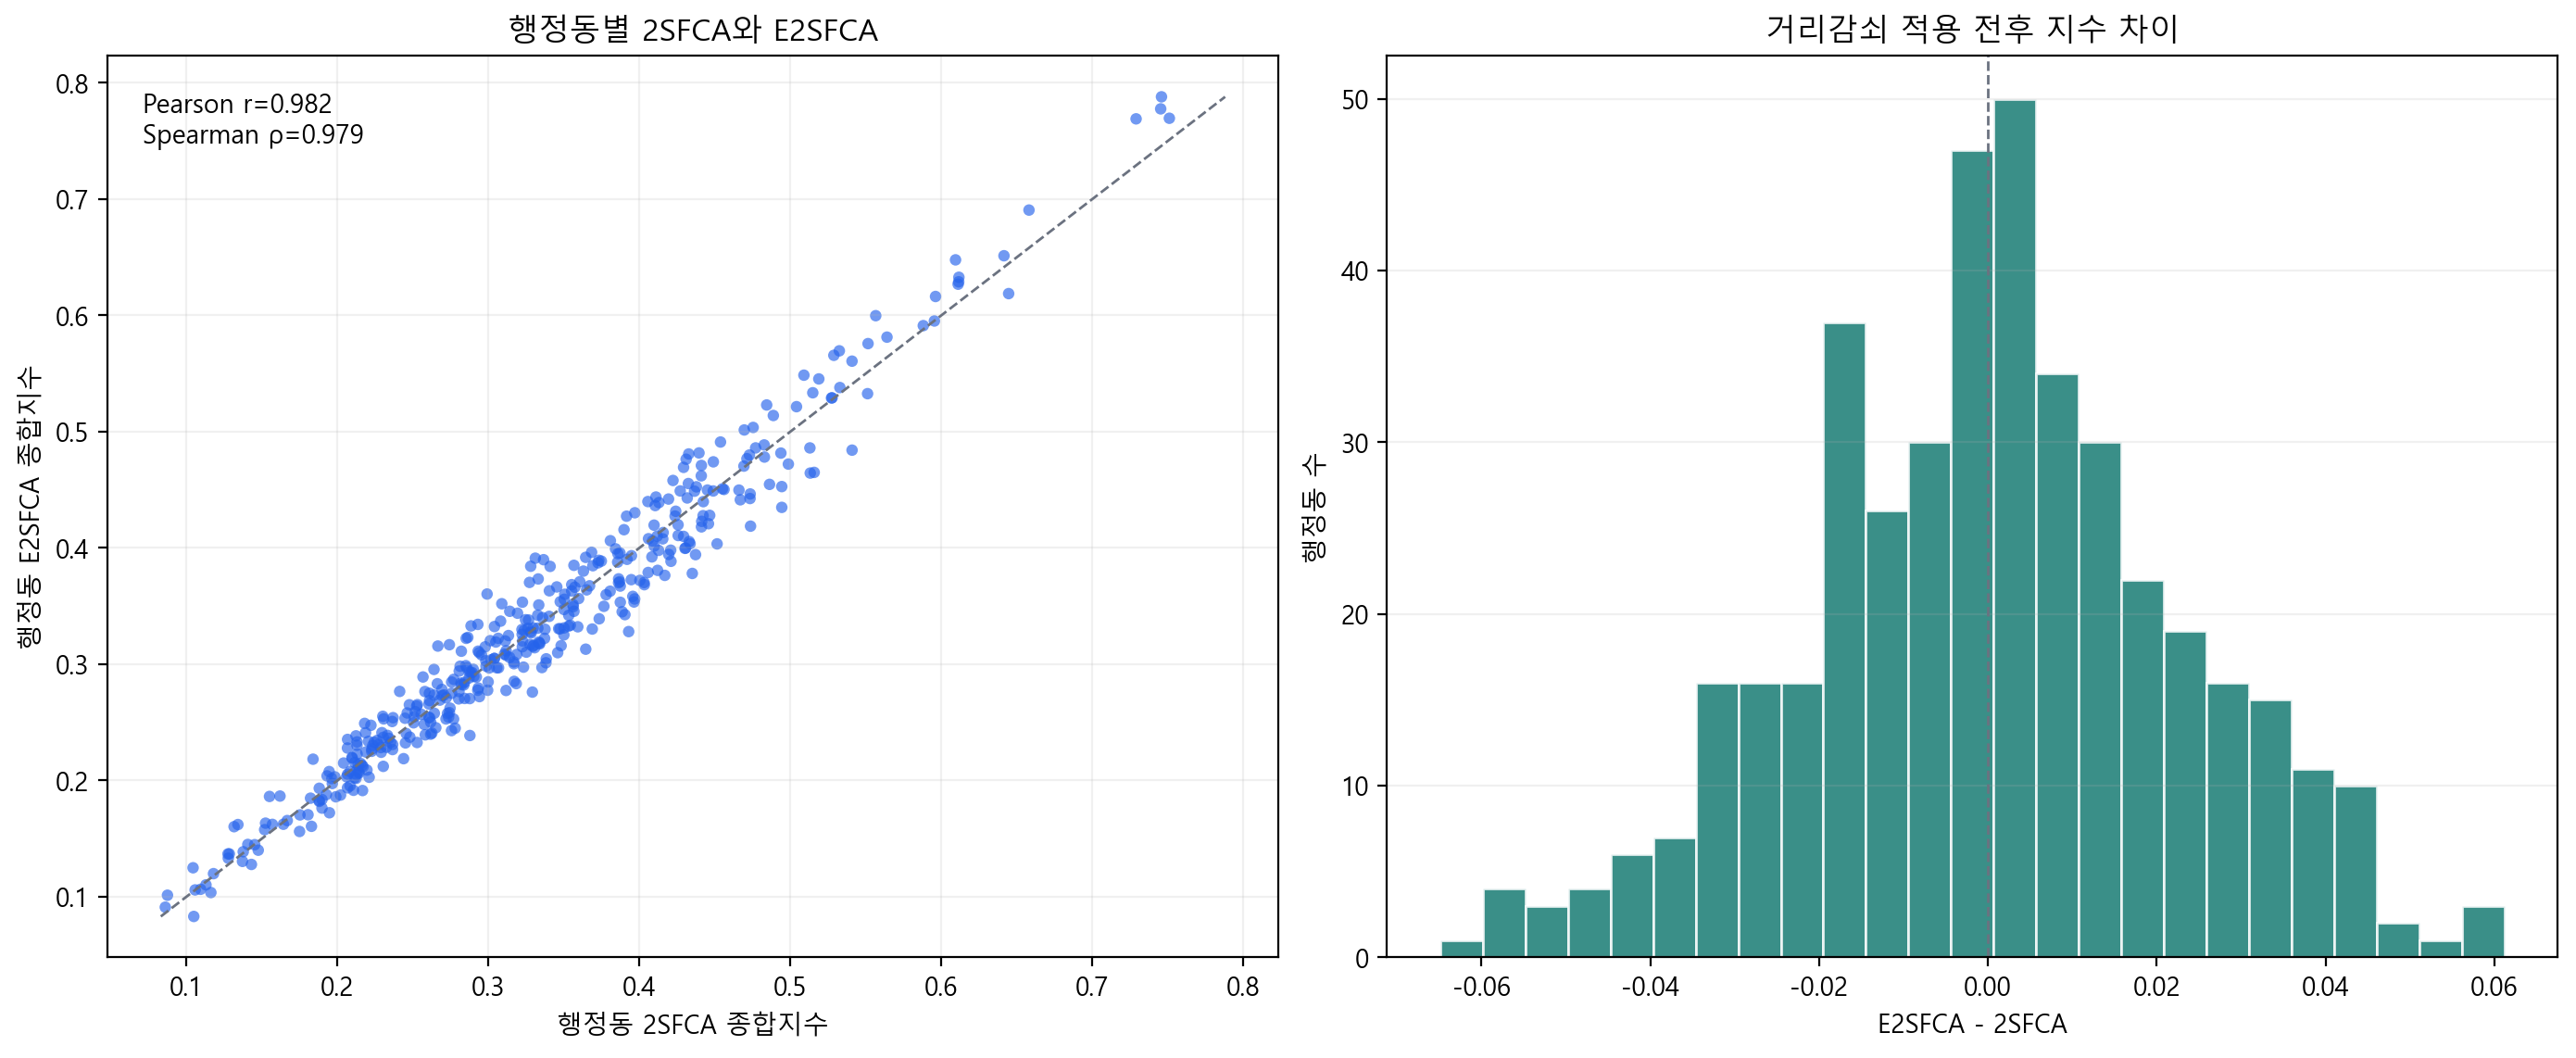

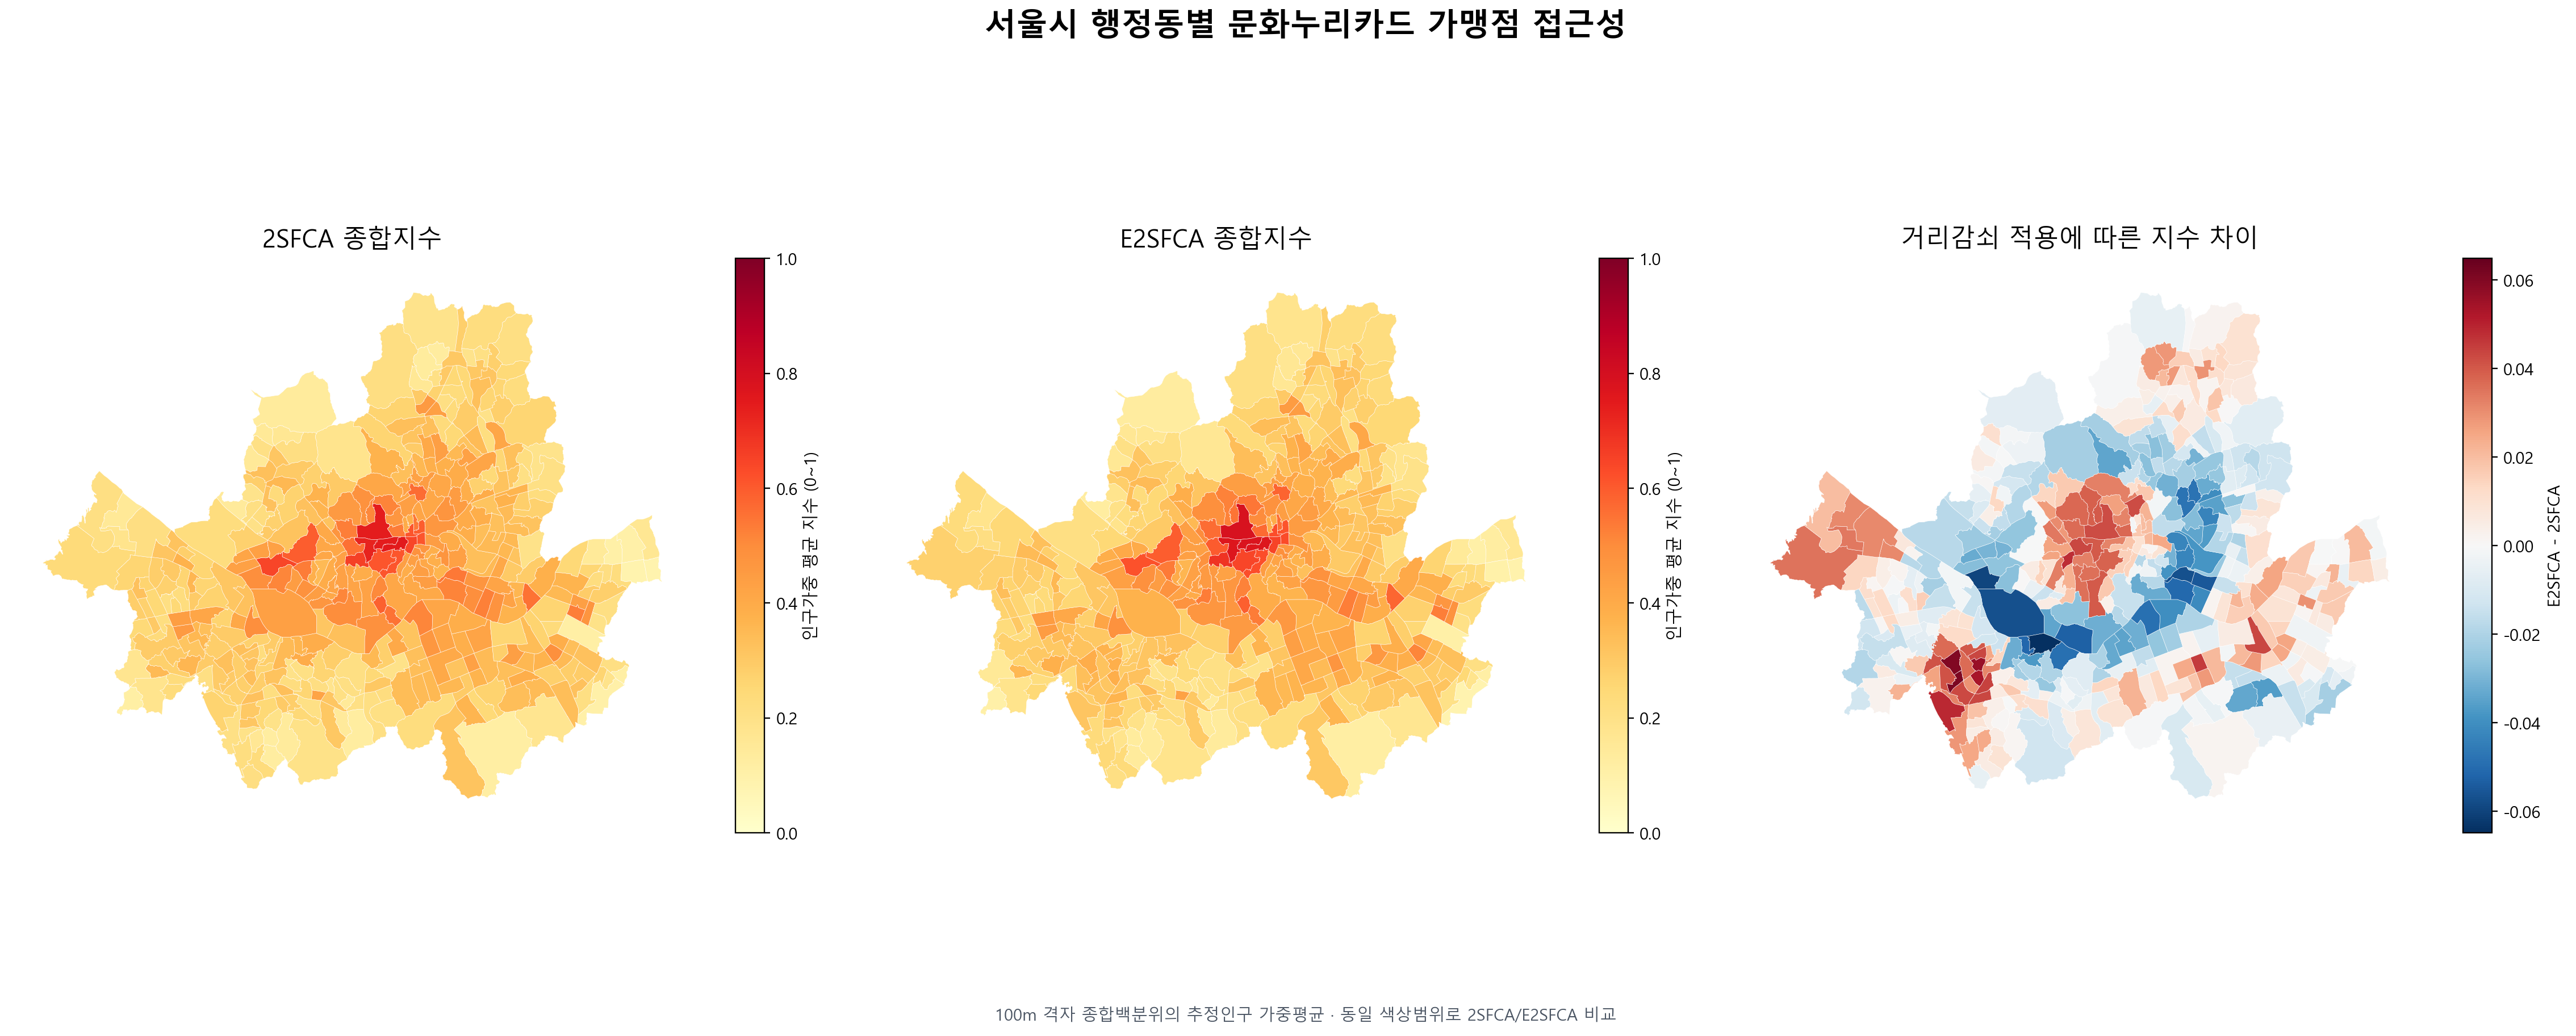

In [2]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import geopandas as gpd

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 산점도와 차이 분포
fig, axes = plt.subplots(1, 2, figsize=(14, 5.8))
axes[0].scatter(dong_eda['2sfca_지수'], dong_eda['e2sfca_지수'], s=20, alpha=.65, color='#2563EB', edgecolors='none')
lo = min(dong_eda['2sfca_지수'].min(), dong_eda['e2sfca_지수'].min())
hi = max(dong_eda['2sfca_지수'].max(), dong_eda['e2sfca_지수'].max())
axes[0].plot([lo,hi],[lo,hi], color='#6B7280', linewidth=1, linestyle='--')
axes[0].set(xlabel='행정동 2SFCA 종합지수', ylabel='행정동 E2SFCA 종합지수', title='행정동별 2SFCA와 E2SFCA')
axes[0].text(.03,.96,f'Pearson r={pearson:.3f}\nSpearman ρ={spearman:.3f}',transform=axes[0].transAxes,va='top')
axes[0].grid(alpha=.18)

axes[1].hist(dong_eda['e2_minus_2sfca'], bins=25, color='#0F766E', alpha=.82, edgecolor='white')
axes[1].axvline(0, color='#6B7280', linewidth=1, linestyle='--')
axes[1].set(xlabel='E2SFCA - 2SFCA', ylabel='행정동 수', title='거리감쇠 적용 전후 지수 차이')
axes[1].grid(axis='y',alpha=.18)
fig.tight_layout()
fig.savefig(EDA_PLOT_PNG, dpi=200, bbox_inches='tight', facecolor='white')
plt.close(fig)

# 서울 행정동 경계 결합
boundary = gpd.read_file(BOUNDARY_GPKG)
for col in ['시군구','행정동']:
    boundary[col] = boundary[col].astype(str).str.strip()
seoul = boundary.merge(dong_eda, on=['시군구','행정동'], how='left', validate='one_to_one')
unmatched = int(seoul['2sfca_지수'].isna().sum())
if unmatched:
    print(f'경고: 행정동 경계 중 지수 미결합 {unmatched}개')

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
map_specs = [
    ('2sfca_지수','2SFCA 종합지수','YlOrRd',None),
    ('e2sfca_지수','E2SFCA 종합지수','YlOrRd',None),
]
for ax,(column,title,cmap,norm) in zip(axes[:2],map_specs):
    seoul.plot(column=column,cmap=cmap,vmin=0,vmax=1,linewidth=.18,edgecolor='white',legend=True,
               legend_kwds={'label':'인구가중 평균 지수 (0~1)','shrink':.66},missing_kwds={'color':'#D1D5DB'},ax=ax)
    ax.set_title(title,fontsize=15,pad=12); ax.set_axis_off()

diff_limit = float(np.nanmax(np.abs(seoul['e2_minus_2sfca'])))
diff_limit = diff_limit if diff_limit > 0 else 1e-6
seoul.plot(column='e2_minus_2sfca',cmap='RdBu_r',norm=TwoSlopeNorm(vmin=-diff_limit,vcenter=0,vmax=diff_limit),
           linewidth=.18,edgecolor='white',legend=True,legend_kwds={'label':'E2SFCA - 2SFCA','shrink':.66},
           missing_kwds={'color':'#D1D5DB'},ax=axes[2])
axes[2].set_title('거리감쇠 적용에 따른 지수 차이',fontsize=15,pad=12); axes[2].set_axis_off()
fig.suptitle('서울시 행정동별 문화누리카드 가맹점 접근성',fontsize=19,fontweight='bold',y=.97)
fig.text(.5,.03,'100m 격자 종합백분위의 추정인구 가중평균 · 동일 색상범위로 2SFCA/E2SFCA 비교',ha='center',fontsize=10,color='#4B5563')
fig.tight_layout(rect=[0,.05,1,.94])
fig.savefig(HEATMAP_PNG,dpi=210,bbox_inches='tight',facecolor='white')
plt.close(fig)

print(f'행정동 EDA 그래프 저장: {EDA_PLOT_PNG}')
print(f'서울 행정동 히트맵 저장: {HEATMAP_PNG}')
print(f'경계 {len(boundary):,}개 / 지수 결합 {seoul["2sfca_지수"].notna().sum():,}개 / 미결합 {unmatched:,}개')
